Cell 1: Environmental Preparation

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.autograd import Variable
import torchvision
from torchvision import transforms, datasets, models
from torchvision.models import ResNet50_Weights
from torchvision.transforms import autoaugment

%matplotlib inline

Cell 2: Hardware Detection

In [2]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.6.0+cu126
True
NVIDIA GeForce RTX 4090


Cell 3: Data Preparation

In [3]:
dataTrans = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.5461, 0.5460, 0.5675], [0.1151, 0.1151, 0.0822]) #The Mean And Standard Deviation of The Customize Dataset
    ]),
    'val': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.5461, 0.5460, 0.5675], [0.1151, 0.1151, 0.0822]) #The Mean And Standard Deviation of The Customize Dataset
    ]),
    'test': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.5461, 0.5460, 0.5675], [0.1151, 0.1151, 0.0822]) #The Mean And Standard Deviation of The Customize Dataset
    ])
}

#Data Path Configuration
train_data_dir = './data/UniAut/train'
val_data_dir = './data/UniAut/val'
test_data_dir ='./data/UniAut/test'

#Creating Datasets
train_dataset = datasets.ImageFolder(train_data_dir, dataTrans['train'])
val_dataset = datasets.ImageFolder(val_data_dir, dataTrans['val'])
test_dataset = datasets.ImageFolder(val_data_dir, dataTrans['test'])

image_datasets = {'train': train_dataset, 'val': val_dataset, 'test': test_dataset}

#Creating DataLoader（Notice The Validation Set off shuffle）
dataloaders = {
    'train': torch.utils.data.DataLoader(
        image_datasets['train'],
        batch_size=128,
        shuffle=True,
        num_workers=8,
        pin_memory=True  #Acceleration, CPU→GPU, Data Transmission
    ),
    'val': torch.utils.data.DataLoader(
        image_datasets['val'],
        batch_size=128,
        shuffle=False,  #Must Be Turned off shuffle
        num_workers=8,
        pin_memory=True  #Acceleration, CPU→GPU, Data Transmission
    ),
    'test': torch.utils.data.DataLoader(
        image_datasets['test'],
        batch_size=128,
        shuffle=False,  #Must Be Turned off shuffle
        num_workers=8,
        pin_memory=True  #Acceleration, CPU→GPU, Data Transmission
    )
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}

# Device Detection
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda:0 device


Cell 4: Model Definition

In [4]:
def initialize_model(num_classes):
    model = models.resnet50(weights=ResNet50_Weights.DEFAULT).to(device)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

print(len(train_dataset.classes))
model_ft = initialize_model(len(train_dataset.classes)).to(device)
loss_func = nn.CrossEntropyLoss().to(device)
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-2, weight_decay=1e-4)  # 添加 weight_decay
exp_lr_scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, 
    mode='min',  #Adjusted by Validation Set Loss
    factor=0.2,  #Learning Rate Scaling Factor
    patience=5   #Number of Epochs That Tolerate No Performance Improvement in The Validation Set
)

135


Cell 5: Training Function

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=50, patience=10):
    """
    Model training with support for early stopping.
    Args:
        model: The Model to Be Trained.
        criterion: Loss Function.
        optimizer: Optimizer.
        scheduler: Learning Rate Scheduler.
        num_epochs: Maximum Number of Training Epochs.
        patience: Number of Epochs With No Improvement After Which Training Will Be Stopped.
    Returns:
        model: The Trained Model.
        history: Dictionary Containing Loss And Accuracy History.
    """
    best_model_wts = model.state_dict()
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    no_improve_epochs = 0  #Record The Number of Consecutive Unboosted Epochs

    #Record The Start Time of Training
    total_start_time = time.time()

    for epoch in range(num_epochs):
        print(f'\n{"="*10} Epoch {epoch+1}/{num_epochs} {"="*10}')
        epoch_start = time.time()

        for phase in ['train', 'val']:
            running_loss = 0.0
            running_corrects = 0
            
            model.train() if phase == 'train' else model.eval()
            
            with tqdm(dataloaders[phase], unit="batch", ncols=100) as tepoch:
                for inputs, labels in tepoch:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                    tepoch.set_postfix(loss=loss.item(), accuracy=(torch.sum(preds == labels.data).item()/inputs.size(0)))

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.cpu().numpy())

            if phase == 'val':
                #Check If Validation Set Accuracy Improves
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
                    no_improve_epochs = 0  #Reset Unlifted Counter
                else:
                    no_improve_epochs += 1  #Unlifted, Counter + 1

        #Calling The ReduceLROnPlateau Scheduler
        scheduler.step(history['val_loss'][-1])

        epoch_end = time.time()
        print(f'Epoch {epoch+1} complete in {epoch_end - epoch_start:.2f}s')
        print(f"Train Loss: {history['train_loss'][-1]:.4f}, Train Acc: {history['train_acc'][-1]:.4f}")
        print(f"Val Loss: {history['val_loss'][-1]:.4f}, Val Acc: {history['val_acc'][-1]:.4f}\n")
        
        #Print Current Learning Rate
        current_lr = scheduler.optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr:.6f}")
        
        #Check If It Need To Stop Early
        if no_improve_epochs >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs. No improvement for {patience} consecutive epochs.")
            break

    #Record The Stop Time of Training
    total_end_time = time.time()
    total_time = total_end_time - total_start_time

    #Loading Optimal Model Weights
    model.load_state_dict(best_model_wts)

    #Output Total Training Time And Best Validation Accuracy
    print(f"Training complete in {total_time // 60:.0f}m {total_time % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    return model, history

Cell 6: Model Training

In [6]:
model_ft, history = train_model(
    model=model_ft,
    criterion=loss_func,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler,
    num_epochs=50,
    patience=10
)


========== Epoch 1/50 ==========


100%|██████████████████████████████| 210/210 [02:18<00:00,  1.52batch/s, accuracy=0.0469, loss=3.59]


Epoch 1 complete in 601.94s
Train Loss: 4.0685, Train Acc: 0.0820
Val Loss: 3.5781, Val Acc: 0.1690

Current Learning Rate: 0.010000

========== Epoch 2/50 ==========


100%|███████████████████████████████| 210/210 [02:17<00:00,  1.53batch/s, accuracy=0.422, loss=4.61]


Epoch 2 complete in 590.82s
Train Loss: 1.6440, Train Acc: 0.5432
Val Loss: 3.7154, Val Acc: 0.4228

Current Learning Rate: 0.010000

========== Epoch 3/50 ==========


...

Epoch 48 complete in 586.25s
Train Loss: 0.1325, Train Acc: 0.9653
Val Loss: 0.1345, Val Acc: 0.9648

Current Learning Rate: 0.000400

========== Epoch 49/50 ==========


100%|██████████████████████████████| 210/210 [02:17<00:00,  1.53batch/s, accuracy=0.945, loss=0.188]


Epoch 49 complete in 585.45s
Train Loss: 0.1329, Train Acc: 0.9653
Val Loss: 0.1124, Val Acc: 0.9709

Current Learning Rate: 0.000400

========== Epoch 50/50 ==========


100%|██████████████████████████████| 210/210 [02:17<00:00,  1.53batch/s, accuracy=0.977, loss=0.112]

Epoch 50 complete in 585.96s
Train Loss: 0.1322, Train Acc: 0.9652
Val Loss: 0.1191, Val Acc: 0.9686

Current Learning Rate: 0.000400
Training complete in 442m 20s
Best val Acc: 0.9709


Cell 7: Save Training Data

In [ ]:
#Save Training History Data
import pandas as pd

#Save Training And Validation Loss and Accuracy to .csv File
def save_history_to_csv(history, output_path):
    """
    Save Training And Validation Loss and Accuracy to .csv File.
    Args:
        history: Dictionaries Contains Training And Validation Loss and Accuracy.
        output_path: Path to The Saved .csv file.
    """
    #Creating DataFrame
    df = pd.DataFrame({
        'Epoch': range(1, len(history['train_loss']) + 1),
        'Train Loss': history['train_loss'],
        'Train Accuracy': history['train_acc'],
        'Validation Loss': history['val_loss'],
        'Validation Accuracy': history['val_acc']
    })

    #Saved as .csv file
    df.to_csv(output_path, index=False)
    print(f"The Training History Has Been Saved As: {output_path}")


#Calling The save_history_to_csv Function
history_output_path = './results/UniAut/training_history_0411_1.csv'  #Save Path
save_history_to_csv(history, history_output_path)

训练历史已保存为: ./results/UniAut5/training_history_0411_1.csv


In [12]:
best_acc = max(history['val_acc'])
print(f"Best Validation Accuracy: {best_acc:.4f}")

Best Validation Accuracy: 0.9709


In [ ]:
#Save Training Status
torch.save({
    'epoch': 50 + 1,
    'model_state_dict': model_ft.state_dict(),
    'optimizer_state_dict': optimizer_ft.state_dict(),
    'scheduler_state_dict': exp_lr_scheduler.state_dict(),
    'history': history,
    'best_acc': best_acc
}, './models/UniAut/checkpoint_0411.pth')

In [ ]:
#Load Training Status
checkpoint = torch.load('./models/UniAut/checkpoint_0411.pth', weights_only=False)
model_ft.load_state_dict(checkpoint['model_state_dict'])
optimizer_ft.load_state_dict(checkpoint['optimizer_state_dict'])
exp_lr_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
history = checkpoint['history']
best_acc = checkpoint['best_acc']
start_epoch = checkpoint['epoch']

In [ ]:
#Continue Training
model_ft, history = train_model(
    model=model_ft,
    criterion=loss_func,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler,
    num_epochs=20,  #Total Training Epochs
    patience=5
)


========== Epoch 1/20 ==========


100%|██████████████████████████████| 210/210 [02:16<00:00,  1.54batch/s, accuracy=0.984, loss=0.109]


Epoch 1 complete in 590.21s
Train Loss: 0.1323, Train Acc: 0.9655
Val Loss: 0.1180, Val Acc: 0.9706

Current Learning Rate: 0.000400

========== Epoch 2/20 ==========


100%|█████████████████████████████| 210/210 [02:16<00:00,  1.54batch/s, accuracy=0.984, loss=0.0861]


Epoch 2 complete in 582.79s
Train Loss: 0.1290, Train Acc: 0.9664
Val Loss: 0.1178, Val Acc: 0.9704

Current Learning Rate: 0.000400

========== Epoch 3/20 ==========


...

Epoch 18 complete in 591.15s
Train Loss: 0.1093, Train Acc: 0.9719
Val Loss: 0.0936, Val Acc: 0.9770

Current Learning Rate: 0.000080

========== Epoch 19/20 ==========


100%|█████████████████████████████| 210/210 [02:16<00:00,  1.54batch/s, accuracy=0.992, loss=0.0467]


Epoch 19 complete in 581.20s
Train Loss: 0.1093, Train Acc: 0.9720
Val Loss: 0.0963, Val Acc: 0.9759

Current Learning Rate: 0.000080

========== Epoch 20/20 ==========


100%|██████████████████████████████| 210/210 [02:16<00:00,  1.54batch/s, accuracy=0.961, loss=0.172]

Epoch 20 complete in 586.69s
Train Loss: 0.1091, Train Acc: 0.9727
Val Loss: 0.0955, Val Acc: 0.9759

Current Learning Rate: 0.000080
Training complete in 195m 56s
Best val Acc: 0.9772


In [ ]:
#Breakpoint Retraining
checkpoint_path = './models/checkpoint.pth'

#First Training
model_ft, history = train_model(
    model=model_ft,
    criterion=loss_func,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler,
    num_epochs=50,
    patience=5,
    checkpoint_path=checkpoint_path
)

#If The Training Is Not Effective, You Can Continue To Train
continue_training = input("Training Completed, Continue Training Or Not？(y/n): ").strip().lower()
if continue_training == 'y':
    #Load Checkpoint And Continue Training
    checkpoint = torch.load(checkpoint_path)
    start_epoch = checkpoint['epoch']
    model_ft, history = train_model(
        model=model_ft,
        criterion=loss_func,
        optimizer=optimizer_ft,
        scheduler=exp_lr_scheduler,
        num_epochs=100,  #Total Training Epochs
        patience=5,
        checkpoint_path=checkpoint_path,
        start_epoch=start_epoch
    )

Cell 8: Visualize The Training Process

In [22]:
#Plot And Save The Loss Curve
plt.figure(figsize=(8, 6))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
loss_output_path = './results/UniAut/training_loss_curve_0411_1.png'  #Save Path
plt.savefig(loss_output_path, dpi=300, bbox_inches='tight')  #Increase dpi To Ensure Clarity
print(f"Loss curve save as: {loss_output_path}")
plt.close()  #Close The Current Image To Avoid Conflicts With Subsequent Drawings

# 绘制 Accuracy 曲线并保存
plt.figure(figsize=(8, 6))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
accuracy_output_path = './results/UniAut5/training_accuracy_curve_0411_1.png'  #Save Path
plt.savefig(accuracy_output_path, dpi=300, bbox_inches='tight')  #Increase dpi To Ensure Clarity
print(f"Accuracy curve save as: {accuracy_output_path}")
plt.close()  #Close The Current Image To Avoid Conflicts With Subsequent Drawings

Loss 曲线已保存为: ./results/UniAut5/training_loss_curve_0411_2.png
Accuracy 曲线已保存为: ./results/UniAut5/training_accuracy_curve_0411_2.png


Cell 9: ROC/AUC Visualization

Generating predictions: 100%|█████████████████████████████████████| 210/210 [01:24<00:00,  2.49it/s]


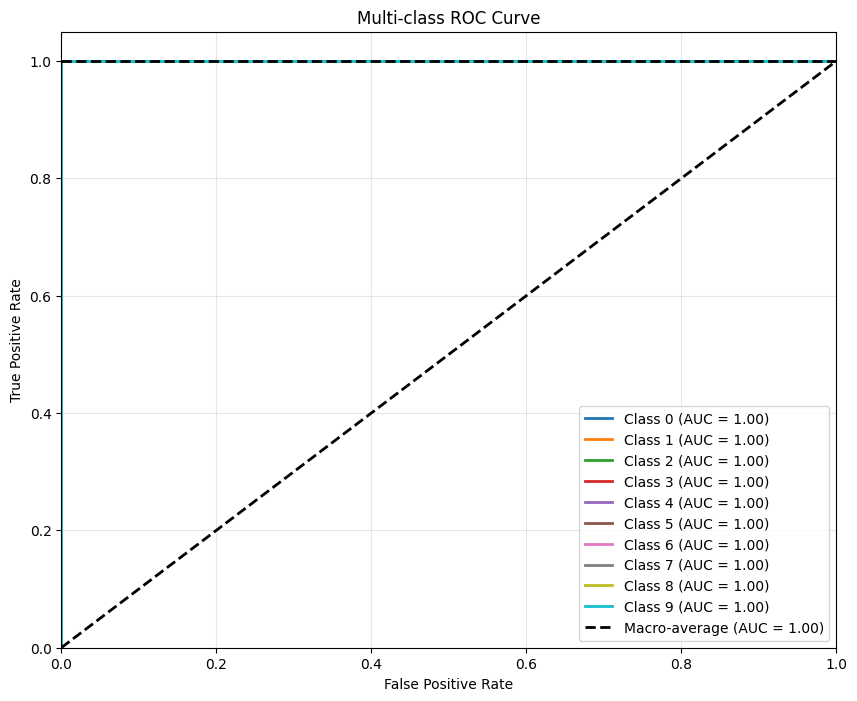

In [8]:
def plot_roc_curve(model, dataloader):
    model.eval()
    y_true = []
    y_scores = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Generating predictions", ncols=100):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)
            y_scores.extend(probabilities.cpu().numpy())
            y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    n_classes = y_scores.shape[1]

    # Binarize labels
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    #Calculate ROC Curves For Each Category
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    #Plot Curve
    plt.figure(figsize=(10, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
             '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    for i, color in zip(range(n_classes), colors[:n_classes]):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    #Plot Average Curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, 'k--', label=f'Macro-average (AUC = {macro_auc:.2f})', lw=2)

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

#Run plot_roc_curve
plot_roc_curve(model_ft, dataloaders['test'])

In [13]:
print(f"Number of classes in training set: {len(train_dataset.classes)}")
print(f"Number of classes in validation set: {len(val_dataset.classes)}")
print(f"Number of classes in test set: {len(test_dataset.classes)}")

Number of classes in training set: 135
Number of classes in validation set: 135
Number of classes in test set: 135


Cell 10: Save Model

In [23]:
#Save The Full Model Object With Structure
torch.save(model_ft, "./models/UniAut/model_0411_1.pt")

#Loading Method (Requires Model Classes To Be Defined In Scope)
#loaded_model = torch.load("./models/UniAut/model.pt")

torch.save(model_ft.state_dict(), './models/UniAut/model_0411_1.pth', _use_new_zipfile_serialization=False)

#Save Training Data
import pickle
with open('./results/UniAut/record.pkl','wb') as f:
    pickle.dump(history,f)

#Load Training Data
import pickle
with open('./results/UniAut/record.pkl','rb') as f:
    data = pickle.load(f)

Cell 11: Classification Accuracy Analysis And Category Statistics

In [24]:
#Getting The Actual Category Name
classes = train_dataset.classes  #Automatically Retrieve Category Names From The Dataset
num_classes = len(classes)

#Initializing The Statistics Container
class_correct = [0.] * num_classes
class_total = [0.] * num_classes
y_test, y_pred = [], []

with torch.no_grad():
    model_ft.eval()
    
    #Adding A Progress Bar
    with tqdm(dataloaders['test'], desc="Class Accuracy Analysis", ncols=100) as pbar:
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model_ft(images)
            _, predicted = torch.max(outputs, 1)
            
            #Moving Data Back To The CPU
            predicted = predicted.cpu()
            labels = labels.cpu()
            
            #Statistically Correct Prediction
            corrects = (predicted == labels).squeeze()
            for i in range(labels.size(0)):
                label = labels[i].item()
                class_correct[label] += corrects[i].item()
                class_total[label] += 1
            
            #Collection Of Projections
            y_pred.extend(predicted.numpy())
            y_test.extend(labels.numpy())

#Print Classification Report
print("\n{:=^50}".format(" Class-wise Accuracy "))
for i in range(num_classes):
    if class_total[i] > 0:
        acc = 100 * class_correct[i] / class_total[i]
        print(f"Accuracy of {classes[i]:15s}: {acc:6.2f}% ({class_correct[i]:.0f}/{class_total[i]:.0f})")
    else:
        print(f"Class {classes[i]} has no samples")

#Total Accuracy
total_acc = 100 * np.sum(class_correct) / np.sum(class_total)
print("\n{:=^50}".format(f" Total Accuracy: {total_acc:.2f}% "))

Class Accuracy Analysis: 100%|████████████████████████████████████| 210/210 [02:21<00:00,  1.48it/s]


============== Class-wise Accuracy ===============
Accuracy of SE01           :  97.47% (193/198)
Accuracy of SE02           :  98.99% (196/198)
Accuracy of SE03           :  98.99% (196/198)
Accuracy of SE04           :  99.49% (197/198)
Accuracy of SE05           :  98.99% (196/198)
Accuracy of SE06           :  99.49% (197/198)
Accuracy of SE07           :  96.97% (192/198)
Accuracy of SE08           :  98.48% (195/198)
Accuracy of SE09           :  97.98% (194/198)
Accuracy of SE10           :  93.94% (186/198)
Accuracy of SE100          :  98.00% (196/200)
Accuracy of SE101          :  98.50% (197/200)
Accuracy of SE102          :  99.00% (198/200)
Accuracy of SE103          :  99.00% (198/200)
Accuracy of SE104          :  96.00% (192/200)
Accuracy of SE105          : 100.00% (200/200)
Accuracy of SE106          :  97.50% (195/200)
Accuracy of SE107          :  97.50% (195/200)
Accuracy of SE108          :  99.00% (198/200)
Accuracy of SE109          : 100.00% (200/200)
Accuracy

Cell 12: Confusion Matrix Visualization

<Figure size 1000x1000 with 0 Axes>

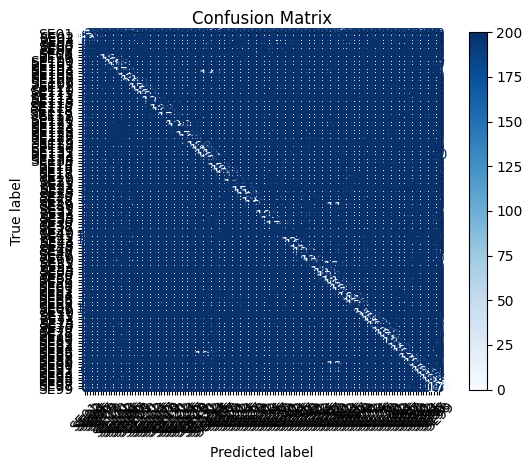

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

#Save Confusion Matrix As .csv file
cm_df = pd.DataFrame(cm, index=classes, columns=classes)  #Use Category Names As Labels For Rows And Columns
cm_csv_path = './confusion_matrix_uniaut_0411_1.csv'
cm_df.to_csv(cm_csv_path, index=True)
print(f" Confusion Matrix has saved as .csv file: {cm_csv_path}")

混淆矩阵已保存为 CSV 文件: ./confusion_matrix_uniaut5_0411_2.csv


Cell 13: Model Test Function

In [18]:
def create_test_pipeline(model_path, label_map):
    #Creating Reusable Test Flows
    def predict(image_path, show_image=True):
        """Test Single Image
        Args:
            image_path (str): Test Image Path
            show_image (bool): Whether To Display Images Or Not
        Returns:
            tuple: (Prediction Categories, Dictionary of Probabilities by Category)
        """
        #Image Preprocessing
        image = Image.open(image_path).convert('RGB')
        if show_image:
            plt.figure(figsize=(8, 6))
            plt.imshow(image)
            plt.axis('off')
            plt.show()

        #Pre-processing Pipeline
        transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.5461, 0.5460, 0.5675], [0.1151, 0.1151, 0.0822])
        ])
        
        #Prediction
        with torch.no_grad():
            input_tensor = transform(image).unsqueeze(0).to(device)
            outputs = model(input_tensor)
            probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        
        #Results Analysis
        probs = {label_map[i]: float(prob) for i, prob in enumerate(probabilities.cpu().numpy())}
        predicted_class = label_map[torch.argmax(probabilities).item()]
        return predicted_class, probs

    return predict

Cell 14: Model Test

In [ ]:
#Load The Best Model
model_ft.load_state_dict(torch.load('./model/UniAut/model.pth', map_location=device))
model_ft.eval()

#Getting Category Mapping
label_map = {v: k for k, v in train_dataset.class_to_idx.items()}  #Automatic Acquisition From Training Data

#Creating a Test Pipeline
tester = create_test_pipeline('./model/UniAut/model.pth', label_map)

#Testing A Single Samples
test_image_path = './data/UniAut/test/SE1001.jpg'  #Test Image Path
pred_class, probs = tester(test_image_path)

print(f"\n Predicted Results：{pred_class}")
print("Probability Of Each Category：")
for cls, prob in probs.items():
    print(f"{cls:>15s}: {prob*100:6.2f}%")

Cell 15: Batch Test

In [ ]:
def batch_test(test_dir):
    """Testing Images For An Entire Catalog"""
    image_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    results = []
    for filename in tqdm(image_files, desc="Test Progress", ncols=100):
        img_path = os.path.join(test_dir, filename)
        try:
            pred, _ = tester(img_path, show_image=False)
            results.append((filename, pred))
        except Exception as e:
            print(f"Processing {filename} error: {str(e)}")
    
    print("\n Summary of Test Results：")
    for filename, pred in results:
        print(f"{filename:30s} => {pred}")

#Run batch_test
batch_test('./data/UniAut/test')